In [1]:
# Dependencies installieren (Falls man das Setup im README.md durchgegangen ist, muesste dieser Schritt nicht noetig sein)
# Ausserdem funktioniert irgendwie nicht innerhalb von Jupyter? 

#  Dieser Code ist auch unter https://github.com/afjaramilg/b_mat_1013_numerik_portfolio abrufbar.

# Unkommentieren, falls das funktioniert 
# !pip install matplotlib == 3.10.8
# !pip install numpy == 2.4.2


In [2]:
# Man ueberpruefe anhand dieses Blocks, ob alles installiert wurde
# python 3.14.3
import matplotlib.pyplot as plt # 3.10.8
import numpy as np              # 2.4.2


In [3]:
# Die Funktion an sich
def f(x): 
    return 2/(1 + (x - 2)**2)

lims = [1, 4] # Das "grosse" Intervall

In [ ]:
# Man haette Dasselbe vllt auch mit range() und functools alles relativ knapp machen
# koennen. Oder einfach mit for-Schleifen. Ich mag `yield` und da es 'lazy' ist
# gibt es an Stellen minimal bessere Leistung
def stepper(lims, h):
    """ yield'et bei jedem Aufruf ein Tupel mit dem jetzigen Intervall
    
    Args:
        lims       ([float, float]): Ein 2er-Float-Tupel `[a,b]`. `a` ist die linke Grenze und `b` die Rechte.
        step_count (int):            Anzahl an Schritten/Intervallen

    Yields:
        float:                       Ein Tupel mit den linken und rechten Grenzen eines Intervalls
    """

    # Es gibt keinen objektiven Grund, diese Funktionalitaet zu nutzen, ausser Stil
    a, b = lims     
    while a < b: # Falls b < a von vorne rein, kommt man nicht weiter
        yield (a, a + h) # Bei jedem `next()`, ein 2er-Tupel mit den Grenzen holen
        a += h


In [ ]:
# a) Implementieren Sie die Trapezregel und die Simpsonregel. Das Programm soll als Eingabe 
# die Intervallraender a und b erhalten sowie die Funktion f
def trapezoid(f, lims):
    """ Errechnet die Trapezregel
    Args:
    f    (function(x: float) -> float): Die zu integrierende Funktion
    lims ([float, float]):              Das Intervall, in dem f integriert werden soll.

    Returns:
    float:                              Den Wert der
    """
    a, b = lims
    return ((b - a)/ 2) * (f(a) + f(b)) # Die Trapezregel

def simpson(f, lims):
    """ Errechnet die Simpson
    Args:
    f    (function(x: float) -> float): Die zu integrierende Funktion
    lims ([float, float]):              Das Intervall, in dem f integriert werden soll.

    Returns:
    float:                              Den Wert der
    """
    a, b = lims
    avg = (a + b) / 2
    return ((b - a) / 6) *(f(a) + 4 * f(avg) + f(b)) # Die Simpsonregel

In [ ]:
# b) Implementieren Sie nun die summierte Trapezregel T1(h) sowie die summierte Simpsonregel T2(h). 
# Das Programm soll als Eingabe die Intervallgrenzen a und b, die zu integrierende Funktion f sowie
# die gewuenschte Anzahl n der Teilintervalle [xk, xk+1] erhalten und die entsprechende Naeherung von I(f) ausgeben

# Fuer Teil d moechte ich gern h der Funktion direkt geben koennen anstatt die Schrittanzahl zu errrechnen
def rule_sum_h(rule, f, lims, h):
    """Wendet eine summierte Regel auf eine Funktion f an

    Args:
    rule (function(f: function, lims: [float, float]) -> float): Die Regel, die man anwenden moechte
    f    (function(x: float) -> float):                          Die Funktion, die man integrieren moechte
    lims ([float, float]:                                        Ein 2er-Float-Tupel wie bei `stepper()`
    h    float:                                                  Schrittweite

    Returns:
    float:                                                       Ergebnis der Integration
    """
    steps = stepper(lims, h) # Generiere die einzelnen Intervalle
    T_h = 0                  # Diese Variable soll die Summe enthalten
    for step in steps:
        T_h += rule(f, step) # T_h fuer die Funktion f im Intervall [ step[0], step[1] ] 
    return T_h

def trapezoid_sum(f, lims, step_count):
    """Wendet die summierte Trapezregel auf eine Funktion f an
    
    Args:
    f    (function(x: float) -> float): Die Funktion, die man integrieren moechte
    lims ([float, float]:               Ein 2er-Float-Tupel wie bei `stepper()`
    h    int:                           Anzahl an Schritten

    Returns:
    float:                              Ergebnis der Integration
    """
    
    a, b = lims
    h = (b - a) / step_count # 'Schrittweite'
    return rule_sum_h(trapezoid, f, lims, h)

def simpson_sum(f, lims, step_count):
    """Wendet eine summierte Simpsonregel auf eine Funktion f an

    Args:
    f    (function(x: float) -> float): Die Funktion, die man integrieren moechte
    lims ([float, float]:               Ein 2er-Float-Tupel wie bei `stepper()`
    h    int:                           Anzahl an Schritten

    Returns:
    float:                              Ergebnis der Integration
    """
    
    a, b = lims
    h = (b - a) / step_count # 'Schrittweite'
    return rule_sum_h(simpson, f, lims, h)


In [ ]:
# c) Plotten Sie T1(h) und T2(h) fur n = 1, 2, ..., 30
n_list = list(range(1, 31))

# Alle Ti(h) Werte berechnen
T1_h_list = [trapezoid_sum(f, lims, n) for n in n_list] 
T2_h_list = [simpson_sum(f, lims, n)   for n in n_list]

# Ich moechte ein einziges Window mit 2 Graphiken
fig, (plot1, plot2) = plt.subplots(1, 2, figsize=(10, 4)) # Die Groesse hab ich von einem Beispiel

plot1.plot(n_list, T1_h_list, marker='o')
plot1.set_title('n vs. T1(h)')
plot1.set_xlabel('Anzahl an Schritten (n)')
plot1.set_ylabel('Summierte Trapezregel (T1(h))')


plot2.plot(n_list, T2_h_list, marker='o')
plot2.set_title('n vs. T2(h)')
plot2.set_xlabel('Anzahl an Schritten (n)')
plot2.set_ylabel('Summierte Simpsonregel (T2(h))')

plt.tight_layout()

plt.show()

In [ ]:
# Zusaetzliche statistische Werte

# Die Werte von T1(h) variieren stark fuer n = 1, ..., 5.  
T1p_h_list = T1_h_list[slice(5, -1)]

median_T1  = np.median(T1_h_list)
median_T1p = np.median(T1p_h_list)
median_T2  = np.median(T2_h_list)

var_T1  = np.var(T1_h_list)
var_T1p = np.var(T1p_h_list)
var_T2  = np.var(T2_h_list)
print(f"Mittelwert T1(h): {median_T1}, Varianz T1(h): {var_T1}, T1(h) bei n={len(n_list)}: {T1_h_list[-1]}")
print(f"Mittelwert T2(h): {median_T2}, Varianz T2(h): {var_T2}, T2(h) bei n={len(n_list)}: {T2_h_list[-1]}")
print(f"Mittelwert T1p(h): {median_T1p}, Varianz T1p(h): {var_T1p}")

## Analyse
Offenbar variieren die Werte der summierten Trapezregel mehr als die der summierten Simpsonregel, aber nur fuer die kleinen Werte von `n`. Wenn man sich die Werte ab `n = 6` anguckt, sieht man aehnliche Ergebnisse. Was auf "diminishing returns" hindeuten koennte, sodass ein groesseres `n` (Also hoehere Aufloesung durch ein kleineres Intervall) nicht mehr besonders viel macht fuer die Qualitaet der Ergebnisse.

Man sieht die Simpsonregel erreicht diesen Punkt schneller als die Trapezregel. Danach oszillieren die Beiden aehnlich viel (siehe `Varianz T1p(h)`). Daraus koennte man schliessen, dass die Simpsonregel hier besser Funktioniert. Im Anbetracht des Grades der Funktion (2), wuerde das Sinn ergeben, denn die Trapezregel macht die Interpolation im Grunde durch lineare Polynome.

In [ ]:
# d) Implementieren Sie die Extrapolation fuer die Simpson-Regel...

def make_p_k_kpm(x, x_k, x_kpm, p_kp1_kpm, p_k_kpmm1):
    """Berechnet ( (x - x_{k}) * p_{k+1,...,k+m} - (x - x_{k+m}) * p_{k,...,k+m-1} ) / (x_{k} - x_{k+m})

    Args:
    x         (float): x
    x_k       (float): x_{k}
    x_kpm     (float): x_{k+m}
    p_kp1_kpm (float): p_{k+1,...,k+m}
    p_k_kpmm1 (float): p_{k,...,k+m-1}   

    Returns:
    float:             Das Ergebnis der Rechnung
    """
    return ((x - x_k) * p_kp1_kpm - (x - x_kpm) * p_k_kpmm1) / (x_kpm - x_k)

# Wenn es einen Zettel mit einer Implementation des Neville-Verfahrens gab,
# hat mein Aufgabepartner die Aufgabe damals gemacht.
def neville(x, points):
    """Berechnet anhand von Stuetzpunkten p_{0,...,n}(x) mitm Neville-Schema

    Args:
    x      (float):            Der zu errechnende Punkt
    points ([float, float][]): Die Punkte des zu interpolierenden Polynoms 

    Returns:
    float:                     Das Ergebnis der Rechnung
    """
    
    n = len(points)

    # pi[k] = p_{k,..., k + m}, wobei m der Index der neusten abgeschlossenen
    # Iteration der Schleige A ist. Es gibt ein implizites "sliding window" 
    # von m 'Iterationen' bei jeder position
    pi = [y for [_, y] in points] # p0...pn

    for m in range(1, n): # Schleife A
        for k in range(n - m):
            x_k, _   = points[k]     # x_{k}
            x_kpm, _ = points[k + m] # x_{k+m}
            p_kp1_kpm  = pi[k + 1]   # p_{k+1, ..., k+m}
            p_k_kpmm1  = pi[k]       # p_{k, ..., k+m-1}

            # !! DEBUG !!
            # print(f"x_k: {x_k}, x_kpm: {x_kpm}, p_kp1_kpm: {p_kp1_kpm}, p_k_kpmm1: {p_k_kpmm1}")

            # Errechne p_{k, ..., k + m}. Wir werden p_{k, ..., k + (m - 1)} nicht mehr brauchen, 
            # also wird es ersetzt
            pi[k] = make_p_k_kpm(x, x_k, x_kpm, p_kp1_kpm, p_k_kpmm1) 
        
        # !! DEBUG !!
        #print(f"iter:{m} - {pi}")

    return pi[0]
        

In [ ]:
# Alternative: Man benutzt die Formel aus Beweis 9.13

def make_T_k_kpm(T_kp1_kpm, T_k_kpmm1, h_kpm, h_k, gamma):
    """Errechnet T_{k + 1, ..., k + m} + (T_{k + 1, ..., k + m} - T_{k, ..., k + m - 1})/((h_{k}/h_{k + m})^{gamma} - 1). Siehe 9.13
    
    Args:
    T_kp1_kpm (float): T_{k + 1, ... k + m}
    T_k_kpmm1 (float): T_{k, ... k + m - 1}
    h_kpm     (float): h_{k + m}
    h_k       (float): h_{k}
    gamma     (float): gamma in der Formel. Der Exponent

    Returns:
    float:                     Das Ergebnis der Rechnung
    """
    return T_kp1_kpm + (T_kp1_kpm - T_k_kpmm1)/( (h_k/h_kpm)**gamma -  1)

# Die Indexsyntax ist Skript fuer diese Formel ist verwirrend
# Kontext: Ich hab von einem Freund gehoert, es gibt Aufgaben, wo man die Iterpolation
# bis eine Stop-Bedingung erfuellt ist treiben muss. Das ist zwar nicht bei mir der Fall,
# aber ich dachte mir, dass jz wo ich sowieso mit yield usw. arbeite, kann ich eine 
# 'online' (im Sinne, dass beliebig viele Punkte nimmt) Version machen. 
def extrapolate(f, lims, rule, hseq, gamma):
    """ Extrapoliert eine Funktion f in einem gewissen Intervall anhand einer Folge an h_{k} Werte mit Exponent gamma. Also T(h_k^gamma)

    Args:
    f    (function(x: float) -> float):                           Die Funktion, die man integrieren moechte
    lims ([float, float]:                                         Ein 2er-Float-Tupel wie bei `stepper()`
    rule (function(f: function, lims: [float, float]) -> float):  Welche Regel sollte die Funktion benutzen (e.g Simpson, Trapez)
    hseq (Iter(float)):                                           Eine durchiterables Struktur, die die h_k fuer 
                                                                  die Extrapolation enthaelt
    gamma (float):                                                Der Exponent der Extrapolation


    Returns:
    float: T_0, das Ergebnis der Extrapolation. Siehe 9.4
    """

    # Man braucht alle hi die bisher benutzt wurden
    # In meinem Konzept kann hseq auch ein Generator sein, von daher "indexe" ich hseq 
    # nicht direkt und speichere stattdessen die h's bisher. 
    hi = []

    # Ti[j] = T_{n-j bis n} in der Syntax des Skripts
    # Die Schleife fuegt bei jeder Iteration eine 'Zeile' hinzu (siehe die Abbildung
    # auf s.49 vom Skript). Fuer die neue Zeile braucht man aber nur die letzte
    Ti = []

    # in unserem fall, mach weiter bis hseq ausgeht
    for h in hseq: # h_{n}
        # man koennte hier natuerlich auch eine Stopbedingung einbauen

        n = len(hi) # hi[k] ist immer h_k, und Arrays sind 0-Indexed
        
        T_last = rule_sum_h(rule, f, lims, h) # T_{n}(h), oder p_{n} in die Notation von Neville

        # jm1 = j - 1, wenn j bei 1 anfaengt geht das in die Schleife bei T01 nicht rein,
        # und so sind die Indexe die ich `make_T_k_kpm` mathematisch "richtig" (n - j = k)
        for jm1 in range(len(Ti)):
            T_nmj_n = make_T_k_kpm(T_last, Ti[jm1], h, hi[n - (jm1 + 1)], gamma)

            # T_{k, ..., k + (n - 1)} braucht man nicht mehr
            Ti[jm1] = T_last

            # Stets T_{n - j - 1, n}
            T_last = T_nmj_n

        
        # !! DEBUG !!
        # print(f"Ti: {Ti}")
        # !! DEBUG !!

        
        Ti.append(T_last)
        hi.append(h)

    return Ti[-1]




In [ ]:
# ... wobei Sie die Burlisch-Folge benutzen


# Laut dem Internet ist der Nenner des i-ten Termes der Bulrisch-Folge
# zwei mal den Nenner des (i-2)-ten Termes
# NOTE: die Option j = -1 zu setzen baute ich nur wegen der ueber der Definition
# von `extrapolate()` erklaerten Gruenden ein. Ist aber nicht fuer die Aufgabe relevant 
def burlisch(h, j = -1):
    """Yield'et bei jedem `next()` das naechste Folgenglied der Burlisch-Folge
    h (float): Anfaenglicher Wert
    j (float): Maximaler Gliedindex oder -1, wenn die Folge nie aufhoeren soll

    Yields:
    float: Das naechste Folgenglied
    """
    # Die ersten 3 Werte scheinen fest zu sein
    yield h     # h_{0}
    yield h / 2 # h_{1}
    yield h / 3 # h_{2}

    nim2 = 2 # Nenner von h_{i - 1}
    nim1 = 3 # Nenner von h_{i - 2}
    i = 3   # Index von h_{i}
    while i < j or j == -1:
        ni = (nim2 * 2) # Nenner von h_{i}
        yield h / ni    # h_{i} = h / (2 * Nenner von h_{i-2})

        # Schiebe die sliding window
        nim2 = nim1
        nim1 = ni
        i += 1

In [ ]:
# ... Waehlen Sie gamma = 4
[a, b] = lims
h = (b - a) / 2             # Der Anfangswert
hseq = list(burlisch(h, 5)) # Mach ich wegen des Vergleiches mit T2(h5) zu einer Liste
gamma = 4                   # Der exponent der h's 

#                    v Der Grund warum rule_sum_h() existiert
points = [(h**gamma, rule_sum_h(simpson, f, lims, h)) for h in hseq]
t0_1 = neville(0, points)
t0_2 = extrapolate(f, lims, simpson, hseq, gamma)

T2_h5 = rule_sum_h(simpson, f, lims, hseq[-1])

print(f"t0_1 (neville): {t0_1} vs t0_2 (bew. 9.13): {t0_2} vs T2(h5): {T2_h5}")
print(f"Differenz t0_1 vs T2(h5) (% von T2(h5)) : {abs(T2_h5 - t0_1) / abs(T2_h5) * 100 }%")
print(f"Differenz t0_2 vs T2(h5) (% von T2(h5)) : {abs(T2_h5 - t0_2) / abs(T2_h5) * 100 }%")
print(f"Differenz t0_2 vs t0_1 (% von t0_1) : {abs(t0_1 - t0_2) / abs(t0_1) * 100 }%")

## Analyse
Es ist kein grosser Unterschied zwischen `T2(h5)`, `t0_1`, und `t0_2`. Dass es einen Unterschied zwischen dem Ergebnis des 'puren' Neville-Schemas und des Algorithmus aus Beweis 9.13 kann wohl nur der immanenten Ungenauigkeit der Gleitkomma-Arithmetik zugeschrieben werden, wie am Anfgang des Kurses besprochen. Der Unterschied ist aber unfassbar winzig. `T2(h5)` ist also vermutlich schon ausreichend optimal, dass sich die Extrapolation in diesem Fall nicht ganz lohnt. Laut [integral calculator](https://www.integral-calculator.com/) ist das Ergebnis von beiden ziemlich akkurat.

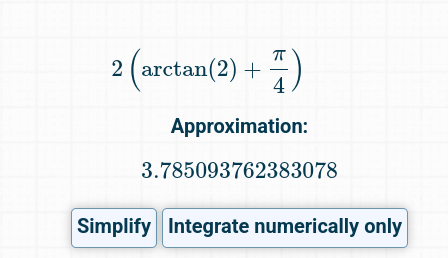